<div style="font-size:30px;font-weight:700;color:#111827;padding-bottom:8px;margin:18px 0;">
CNN CIFAR10 end-to-end 파이프라인
</div>

# CIFAR10 데이터 적재 + 배치 shape·시각화 확인

**목표**: CIFAR10 CIFAR-10 이미지 학습/테스트 데이터를 다운로드해 `DataLoader`로 감싸고, 첫 배치의 shape과 실제 이미지 한 장을 시각으로 확인합니다.

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# CIFAR-10 학습/테스트셋 다운로드
training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

print("Train dataset size:", len(training_data))
print("Test dataset size :", len(test_data))

Train dataset size: 50000
Test dataset size : 10000


In [5]:
# CIFAR-10 클래스 이름
cifar10_classes = test_data.classes
print(cifar10_classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# 학습/테스트 데이터 로더
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_dataloader))
print("Test batches :", len(test_dataloader))

Train batches: 782
Test batches : 157


In [7]:
# 데이터 형태 확인
for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    print(f"Pixel range: [{X.min():.3f}, {X.max():.3f}]")
    break

Shape of X [N, C, H, W]: torch.Size([64, 3, 32, 32])
Shape of y: torch.Size([64]) torch.int64
Pixel range: [0.000, 1.000]


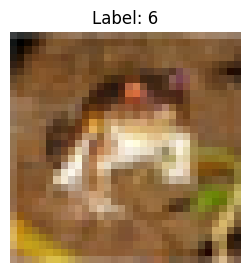

In [8]:
# 한 장 시각화
img, label = training_data[0]
plt.figure(figsize=(3, 3))
plt.imshow(img.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

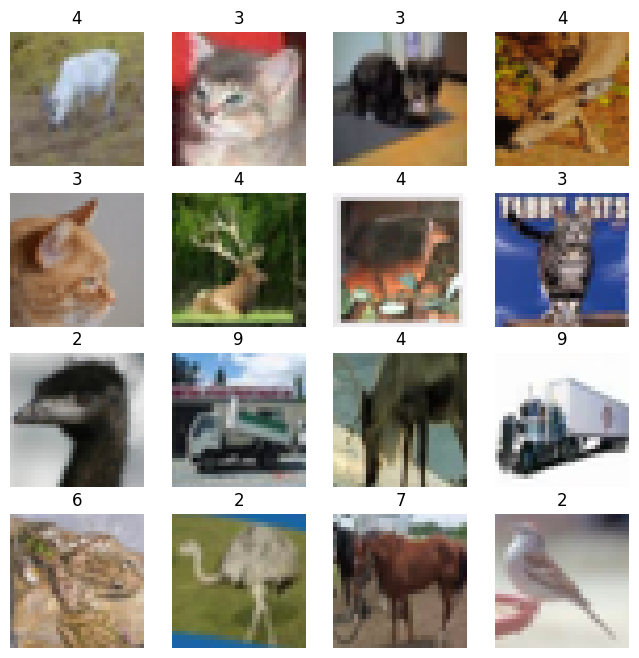

In [9]:
# 여러 장 시각화
figure = plt.figure(figsize=(8, 8))
cols, rows = 4, 4

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]

    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))

plt.show()

# 장치 자동 선택 + Dropout 포함 CNN 모델 정의

**목표**: 가능한 장치(GPU 또는 CPU)를 자동 선택하고, `Conv2d → ReLU → MaxPool2d → Conv2d → ReLU → MaxPool2d → Flatten → Linear → ReLU → Dropout → Linear` 구조의 CNN 모델을 정의합니다.

In [10]:
pip install torchinfo

In [11]:
pip install torchview

In [12]:
from torchinfo import summary
from torchview import draw_graph

In [13]:
# 장치 선택 — GPU가 있으면 GPU, 없으면 CPU
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
device

device(type='cuda')

In [14]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # 입력: (N, 3, 32, 32)
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.3)

        # (N, 3, 32, 32)
        # -> conv1 + pool: (N, 32, 16, 16)
        # -> conv2 + pool: (N, 64, 8, 8)
        # -> conv3 + pool: (N, 128, 4, 4)
        self.flat = nn.Flatten(start_dim=1)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)

        x = self.relu(self.conv2(x))
        x = self.pool(x)

        x = self.relu(self.conv3(x))
        x = self.pool(x)

        x = self.flat(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)

        return self.fc2(x)

In [15]:
model = CNN().to(device)
summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Conv2d: 1-1                            [1, 32, 32, 32]           896
├─ReLU: 1-2                              [1, 32, 32, 32]           --
├─MaxPool2d: 1-3                         [1, 32, 16, 16]           --
├─Conv2d: 1-4                            [1, 64, 16, 16]           18,496
├─ReLU: 1-5                              [1, 64, 16, 16]           --
├─MaxPool2d: 1-6                         [1, 64, 8, 8]             --
├─Conv2d: 1-7                            [1, 128, 8, 8]            73,856
├─ReLU: 1-8                              [1, 128, 8, 8]            --
├─MaxPool2d: 1-9                         [1, 128, 4, 4]            --
├─Flatten: 1-10                          [1, 2048]                 --
├─Linear: 1-11                           [1, 256]                  524,544
├─ReLU: 1-12                             [1, 256]                  --
├

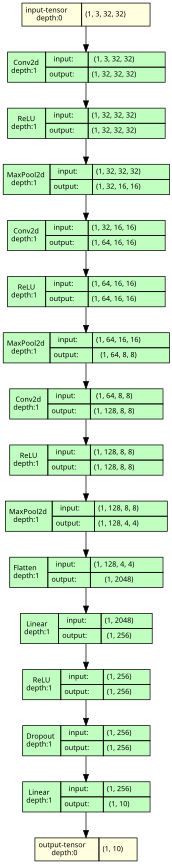

In [16]:
draw_graph(model, input_size=(1, 3, 32, 32)).visual_graph

# 손실·옵티마이저 + 학습/평가 함수 정의

**목표**: `CrossEntropyLoss`와 `Adam` optimizer를 선언하고, 학습 함수 `train()`과 평가 함수 `test()`를 분리해 정의합니다. 각 epoch의 loss와 accuracy를 리스트에 저장해 학습 곡선으로 시각화할 수 있게 합니다.

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [18]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()

    train_loss = 0.0
    correct = 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        if batch % 100 == 0:
            current = (batch + 1) * len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")

    train_loss /= num_batches
    train_acc = correct / size

    return train_loss, train_acc

In [19]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.eval()

    test_loss = 0.0
    correct = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            pred = model(X)

            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    test_acc = correct / size

    print(
        f"Test Error:\n"
        f" Accuracy: {(100 * test_acc):>0.1f}%, "
        f"Avg loss: {test_loss:>8f}\n"
    )

    return test_loss, test_acc

# 5 epoch 학습 실행

**목표**: `train()` + `test()`를 epoch 루프 안에서 호출하여 CIFAR10를 학습합니다. 이 셀은 f-string 줄바꿈 오류가 나지 않도록 `\n`을 사용해 작성되어 있습니다.

In [20]:
epochs = 10

train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for_epoch_message = "Start training"
print(for_epoch_message)

for t in range(epochs):
    print(f"Epoch {t + 1}\n-------------------------------")

    train_loss, train_acc = train(train_dataloader, model, loss_fn, optimizer)
    test_loss, test_acc = test(test_dataloader, model, loss_fn)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

print("Done!")

Start training
Epoch 1
-------------------------------
loss: 2.301213  [   64/50000]
loss: 1.955712  [ 6464/50000]
loss: 1.550149  [12864/50000]
loss: 1.644086  [19264/50000]
loss: 1.626179  [25664/50000]
loss: 1.285985  [32064/50000]
loss: 1.413009  [38464/50000]
loss: 1.381509  [44864/50000]
Test Error:
 Accuracy: 55.0%, Avg loss: 1.241362

Epoch 2
-------------------------------
loss: 1.413383  [   64/50000]
loss: 1.287461  [ 6464/50000]
loss: 1.211979  [12864/50000]
loss: 1.173413  [19264/50000]
loss: 1.221760  [25664/50000]
loss: 1.129371  [32064/50000]
loss: 1.208125  [38464/50000]
loss: 1.031168  [44864/50000]
Test Error:
 Accuracy: 61.8%, Avg loss: 1.085013

Epoch 3
-------------------------------
loss: 1.023609  [   64/50000]
loss: 0.894062  [ 6464/50000]
loss: 0.714358  [12864/50000]
loss: 0.939034  [19264/50000]
loss: 0.973030  [25664/50000]
loss: 1.260736  [32064/50000]
loss: 0.912906  [38464/50000]
loss: 1.102327  [44864/50000]
Test Error:
 Accuracy: 66.6%, Avg loss: 0.955

# 학습 곡선 시각화

**목표**: epoch별 train/test loss와 accuracy 변화를 그래프로 확인합니다.

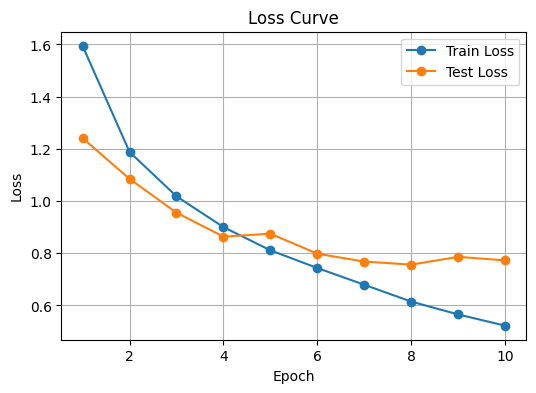

In [21]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, epochs + 1), test_losses, marker="o", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

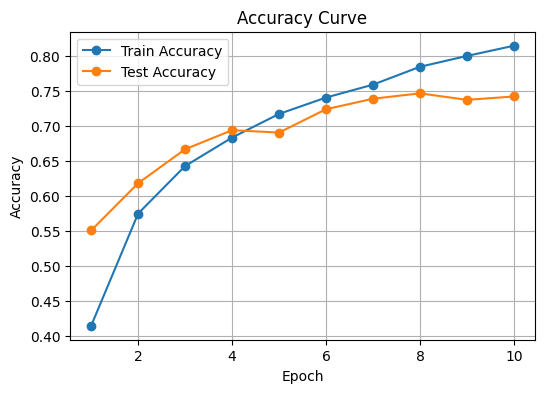

Final Test Accuracy: 74.15%


In [22]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_accuracies, marker="o", label="Train Accuracy")
plt.plot(range(1, epochs + 1), test_accuracies, marker="o", label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.grid(True)
plt.show()

print(f"Final Test Accuracy: {test_accuracies[-1] * 100:.2f}%")

# Confusion Matrix

**목표**: 테스트셋 전체 예측 결과를 이용해 어떤 이미지 클래스끼리 자주 혼동되는지 확인합니다.

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

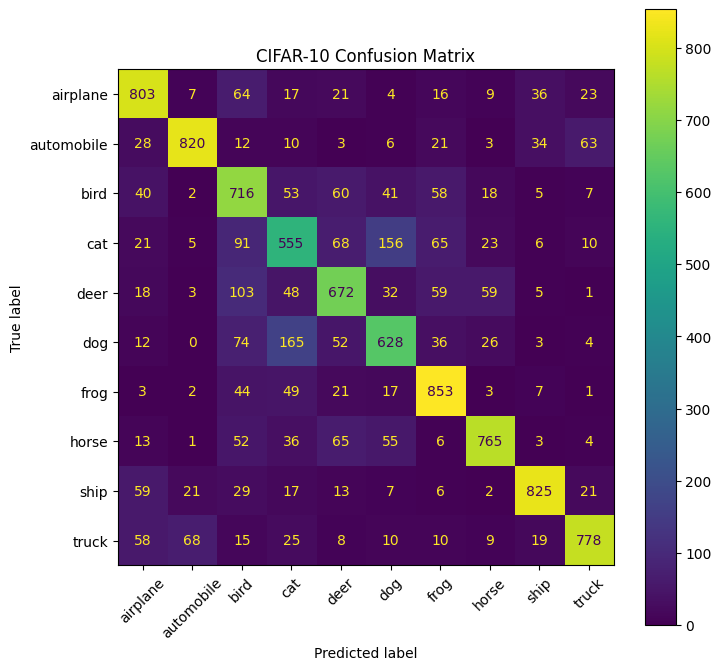

In [24]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X, y in test_dataloader:
        pred = model(X.to(device))

        y_true.extend(y.numpy())
        y_pred.extend(pred.argmax(1).cpu().numpy())

cm = confusion_matrix(y_true, y_pred)

display_labels = test_data.classes

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("CIFAR-10 Confusion Matrix")
plt.show()

In [25]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=display_labels
    )
)

              precision    recall  f1-score   support

    airplane       0.76      0.80      0.78      1000
  automobile       0.88      0.82      0.85      1000
        bird       0.60      0.72      0.65      1000
         cat       0.57      0.56      0.56      1000
        deer       0.68      0.67      0.68      1000
         dog       0.66      0.63      0.64      1000
        frog       0.75      0.85      0.80      1000
       horse       0.83      0.77      0.80      1000
        ship       0.87      0.82      0.85      1000
       truck       0.85      0.78      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



# 테스트 이미지 예측 시각화

**목표**: 테스트 이미지 여러 장에 대해 실제 라벨과 모델 예측 라벨을 함께 확인합니다.

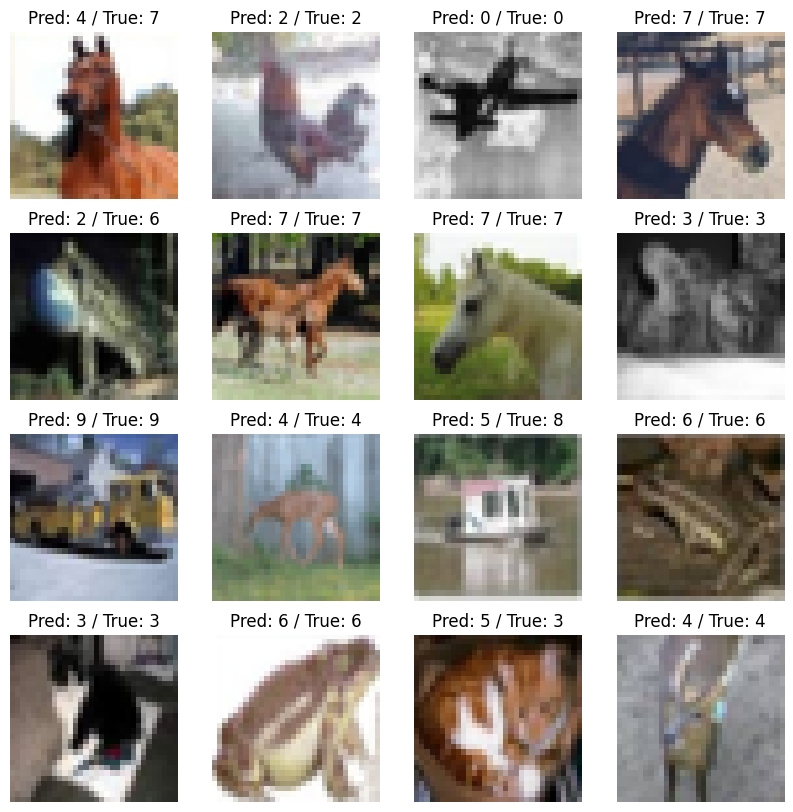

In [26]:
model.eval()

figure = plt.figure(figsize=(10, 10))
cols, rows = 4, 4

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    img, label = test_data[sample_idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        predicted_label = pred.argmax(1).item()

    figure.add_subplot(rows, cols, i)
    plt.title(f"Pred: {predicted_label} / True: {label}")
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))

plt.show()

# 저장 · 재로드 · 단일 추론

**목표**: 학습된 모델 파라미터를 저장하고, 새 `CNN()` 인스턴스에 다시 로드한 뒤 단일 샘플 추론을 수행합니다.

In [27]:
# 저장
torch.save(model.state_dict(), "cnn_cifar10_model.pth")
print("Saved PyTorch Model State to cnn_cifar10_model.pth")

Saved PyTorch Model State to cnn_cifar10_model.pth


In [28]:
# 재로드
loaded_model = CNN().to(device)
loaded_model.load_state_dict(torch.load("cnn_cifar10_model.pth", map_location=device))
loaded_model.eval()

print("Loaded model successfully")

Loaded model successfully


Predicted: "3", Actual: "3"


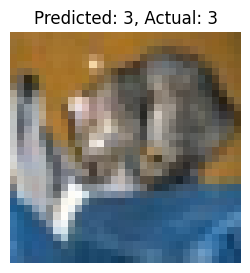

In [29]:
# 단일 추론
x, y = test_data[0][0], test_data[0][1]

with torch.no_grad():
    pred = loaded_model(x.unsqueeze(0).to(device))
    predicted = pred.argmax(1).item()
    actual = y

print(f'Predicted: "{predicted}", Actual: "{actual}"')

plt.figure(figsize=(3, 3))
plt.imshow(x.permute(1, 2, 0))
plt.title(f"Predicted: {predicted}, Actual: {actual}")
plt.axis("off")
plt.show()